# A/B-тестирование: сравнение трёх рекламных промо

---

**Автор:** Александр Калашников

**GitHub:** @AlexK-programming

**Дата:** июнь 2026

---

**Цель:** определить, какое из трёх промо (1, 2 или 3) приводит к наибольшим продажам.

**Данные:** 548 наблюдений, 7 переменных (`MarketID`, `MarketSize`, `LocationID`, `AgeOfStore`, `Promotion`, `week`, `SalesInThousands`).

---

## Содержание

1. Загрузка и первичный осмотр данных
2. Предварительная проверка качества данных
   - Информация о данных (`df.info()`)
   - Описательные статистики (`df.describe()`)
   - Период сбора данных
3. Размер и структура групп промо
4. Визуальный анализ распределения продаж
   - Boxplot: медианы, разброс, выбросы, асимметрия
   - Предварительные выводы
5. Проверка рандомизации
   - 5.1 Распределение `MarketSize` по группам
   - 5.2 Средний возраст магазинов (`AgeOfStore`) по группам
6. Проверка предположений для ANOVA
   - 6.1 Нормальность распределения (тест Шапиро–Уилка)
   - 6.2 Равенство дисперсий (тест Ливена)
7. ANOVA: проверка различий между группами
8. Post-hoc анализ: попарное сравнение (Tukey HSD)
9. Дополнительные метрики
   - 9.1 Средние и медианные продажи по группам
   - 9.2 Относительный эффект (в %)
10. Итоговый вывод
11. Ограничения анализа

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## 1. Загрузка и первичный осмотр данных

In [82]:
df_orig = pd.read_csv('WA_Marketing-Campaign.csv')

df_orig.head()

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81


**Описание переменных:**
- `MarketID` — идентификатор рынка
- `MarketSize` — размер рынка (Small / Medium / Large)
- `LocationID` — идентификатор локации (магазина)
- `AgeOfStore` — возраст магазина (лет)
- `Promotion` — номер промо
- `week` — неделя эксперимента
- `SalesInThousands` — продажи (тыс. долларов)

## 2. Предварительная проверка качества данных

In [83]:
df = df_orig.copy()

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    object 
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), object(1)
memory usage: 30.1+ KB


**Ключевые наблюдения:**

- Пропуски (null) отсутствуют во всех 7 столбцах.

- Объём выборки: 548 наблюдений.

- Типы данных корректны: SalesInThousands - float64, категориальные и идентификационные переменные -/ int64 и object.

- Дополнительной очистки не требуется.

In [85]:
df.describe().round(2)

,MarketID,LocationID,AgeOfStore,Promotion,week,SalesInThousands
count,548.00,548.00,548.00,548.00,548.00,548.00
mean,5.72,479.66,8.50,2.03,2.50,53.47
std,2.88,287.97,6.64,0.81,1.12,16.76
min,1.00,1.00,1.00,1.00,1.00,17.34
25%,3.00,216.00,4.00,1.00,1.75,42.54
50%,6.00,504.00,7.00,2.00,2.50,50.20
75%,8.00,708.00,12.00,3.00,3.25,60.48
max,10.00,920.00,28.00,3.00,4.00,99.65


**Описательные статистики (ключевые выводы):**

**Целевая метрика `SalesInThousands`:**
- Средние продажи: **53.47 тыс.**, медиана: **50.20 тыс.** — близость среднего и медианы указывает на отсутствие сильного смещения.
- Разброс: от **17.34 тыс.** (мин) до **99.65 тыс.** (макс) — значительный диапазон, что обосновывает необходимость группового анализа.
- Стандартное отклонение: **16.76 тыс.** — вариабельность умеренная.

**Контрольные переменные:**
- `AgeOfStore`: средний возраст магазина — **8.5 лет**, разброс от 1 до 28 лет.
- `week`: данные охватывают 4 недели (от 1 до 4), что позволяет оценить краткосрочный эффект.
- `Promotion`: представлены все 3 группы промо.

**Общий вывод:** данные не требуют предварительной очистки, разброс значений ожидаем для розничных продаж. `describe()` даёт количественную характеристику данных, которая будет сопоставлена с визуальным анализом в разделе 4.

### Период сбора данных

In [86]:
print(f"Длительность наблюдений: {df['week'].nunique()} недели")
print(f"Диапазон недель: {df['week'].min()} – {df['week'].max()}")

Длительность наблюдений: 4 недели
Диапазон недель: 1 – 4


**Вывод:** данные охватывают 4 недели (week 1–4). Это позволяет оценить краткосрочный эффект промо.

## 3. Размер и структура групп

In [87]:
df['Promotion'].value_counts()

Promotion
3    188
2    188
1    172
Name: count, dtype: int64

**Вывод:** в данных представлены 3 группы (обозначены как 1, 2 и 3). Размеры групп незначительно отличаются: группа 1 — 172 магазина, группы 2 и 3 — по 188 магазинов. ANOVA устойчив к небольшим различиям в размерах групп (до 10-15%), поэтому данное расхождение не влияет на валидность выводов.

## 4. Визуальный анализ распределения продаж

Text(0.5, 1.0, 'Распределение продаж по группам промо')

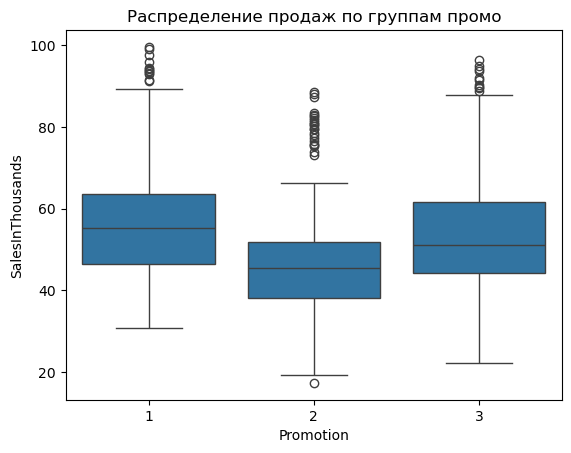

In [88]:
sns.boxplot(data=df, x='Promotion', y='SalesInThousands')
plt.title('Распределение продаж по группам промо')

### Ключевые наблюдения:

**Медианы продаж:**
- Промо 1: ~56 тыс. (наивысшая)
- Промо 3: ~51 тыс. (промежуточная)
- Промо 2: ~46 тыс. (наинизшая)

**Разброс (IQR):**
Во всех группах межквартильный размах составляет примерно 14–17 тыс., что говорит об однородной вариабельности продаж внутри групп. Это важно для корректности ANOVA.

**Выбросы:**
- Выбросы сверху присутствуют во всех трёх группах (аномально высокие продажи)
- Выброс снизу — только в группе 2 (одна точка с аномально низкими продажами)

**Асимметрия:**
- Промо 1 и 3: выраженная правосторонняя асимметрия (верхняя граница выбросов значительно длиннее нижней)
- Промо 2: более симметричное распределение, но с одним нижним выбросом

**Предварительный вывод:**
- Промо 1 показывает наилучшие результаты по всем метрикам — высокая медиана, самая высокая верхняя граница (потенциал роста).
- Промо 2 явно уступает: самая низкая медиана, самая низкая граница выбросов, наличие нижнего выброса.
- Промо 3 близка к Промо 1 по верхней границе, но немного отстаёт по нижней.
- Разница между Промо 1 и Промо 3 на графике менее очевидна — требует статистической проверки.

## 5. Проверка рандомизации
### 5.1 Распределение MarketSize по группам

In [89]:
df.groupby('Promotion')['MarketSize'].value_counts(normalize=True)

Promotion  MarketSize
1          Medium        0.558140
           Large         0.325581
           Small         0.116279
2          Medium        0.574468
           Large         0.340426
           Small         0.085106
3          Medium        0.617021
           Large         0.255319
           Small         0.127660
Name: proportion, dtype: float64

**Вывод:** группы сбалансированны по MarketSize, что является благоприятным условием для проведения ANOVA теста.

### 5.2 Средний возраст магазинов (AgeOfStore) по группам

In [90]:
df.groupby('Promotion')['AgeOfStore'].mean()

Promotion
1    8.279070
2    7.978723
3    9.234043
Name: AgeOfStore, dtype: float64

**Вывод:**
Средний возраст магазинов в группах отличается не более чем на 1.25 года (от 7.98 до 9.23 лет). Различия незначительны и не свидетельствуют о систематическом смещении. Это благоприятный фактор для валидности A/B-теста — возраст магазинов не является искажающим фактором при сравнении промо.

## 6. Проверка предположений для ANOVA
### 6.1 Нормальность распределения (тест Шапиро–Уилка)

In [91]:
shapiro_1 = stats.shapiro(df[df['Promotion'] == 1]['SalesInThousands'])
shapiro_2 = stats.shapiro(df[df['Promotion'] == 2]['SalesInThousands'])
shapiro_3 = stats.shapiro(df[df['Promotion'] == 3]['SalesInThousands'])

print(f"Промо 1: статистика = {shapiro_1.statistic:.2f}, p-value = {shapiro_1.pvalue:.9f}")
print(f"Промо 2: статистика = {shapiro_2.statistic:.2f}, p-value = {shapiro_2.pvalue:.9f}")
print(f"Промо 3: статистика = {shapiro_3.statistic:.2f}, p-value = {shapiro_3.pvalue:.9f}")

Промо 1: статистика = 0.92, p-value = 0.000000020
Промо 2: статистика = 0.91, p-value = 0.000000005
Промо 3: статистика = 0.92, p-value = 0.000000015


**Вывод:** тест Шапиро–Уилка указывает на статистически значимое отклонение от нормальности (p < 0.001), однако ANOVA устойчив к умеренным нарушениям при больших выборках (n > 30).

### 6.2 Равенство дисперсий (тест Ливена)

In [92]:
stat, pvalue = stats.levene(df[df['Promotion'] == 1]['SalesInThousands'], 
                         df[df['Promotion'] == 2]['SalesInThousands'],
                         df[df['Promotion'] == 3]['SalesInThousands'])
print(f'Результат: статистика = {stat:.2f}, p-value = {pvalue:.2f}')

Результат: статистика = 1.27, p-value = 0.28


**Вывод:** дисперсии равны (p = 0.28 > 0.05), предположение ANOVA выполнено.

## 7. ANOVA: проверка различий между группами

In [93]:
f_stat, p_anova = stats.f_oneway(df[df['Promotion'] == 1]['SalesInThousands'],
                                df[df['Promotion'] == 2]['SalesInThousands'],
                                df[df['Promotion'] == 3]['SalesInThousands'])

print(f'Результат ANOVA: статистика = {f_stat:.3f}, p-value = {p_anova:.10f}')

Результат ANOVA: статистика = 21.953, p-value = 0.0000000007


**Вывод:** Различия между группами присутствуют (p < 0.05)

## 8. Post-hoc анализ: попарное сравнение (Tukey HSD)

In [94]:
tukey = pairwise_tukeyhsd(df['SalesInThousands'], df['Promotion'], alpha=0.05)
print(tukey) 

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower    upper  reject
-----------------------------------------------------
     1      2 -10.7696    0.0 -14.7738 -6.7654   True
     1      3  -2.7345 0.2444  -6.7388  1.2697  False
     2      3   8.0351    0.0   4.1208 11.9493   True
-----------------------------------------------------


**Вывод:** Промо 1 превосходит промо 2 в среднем на 10.8 тыс. (95% доверительный интервал: от 6.77 до 14.77 тыс., p < 0.001). Группа 3 занимает среднее положение между 1 и 2 группой. 

## 9. Дополнительные метрики
### 9.1 Средние и медианные продажи по группам

In [95]:
means = df.groupby('Promotion')['SalesInThousands'].mean().round(2)
medians = df.groupby('Promotion')['SalesInThousands'].median().round(2)

print(pd.DataFrame({'Средние': means, 'Медианы': medians}))

           Средние  Медианы
Promotion                  
1            58.10    55.39
2            47.33    45.39
3            55.36    51.16


**Наблюдения:**

- Промо 1 лидирует с отрывом от Промо 2 на **10.77 тыс.** (средние значения)
- Промо 3 занимает промежуточное положение, отставая от Промо 1 на **2.73 тыс.** (средние значения)
- Разрыв между Промо 1 и Промо 3 существенно меньше, чем между Промо 1 и Промо 2
- Медианы (Промо 1: 55.39, Промо 3: 51.16, Промо 2: 45.39) подтверждают тот же порядок и устойчивость результатов.

**Важно:** средние чувствительны к выбросам. Выбросы присутствуют во всех группах равномерно, поэтому сравнение средних между группами корректно (смещение одинаково для всех). Однако абсолютные значения средних могут быть завышены. Для большей надёжности результаты подтверждены медианами (см. визуальный анализ распределения) и статистическими тестами.

### 9.2 Относительный эффект (в %)

In [96]:
print(f"Разница между Промо 1 и Промо 2: +{round(((means[1] - means[2]) / means[2] * 100), 2)}%")
print(f"Разница между Промо 3 и Промо 2: +{round(((means[3] - means[2]) / means[2] * 100), 2)}%")
print(f"Разница между Промо 1 и Промо 3: +{round(((means[1] - means[3]) / means[3] * 100), 2)}%")

Разница между Промо 1 и Промо 2: +22.76%
Разница между Промо 3 и Промо 2: +16.97%
Разница между Промо 1 и Промо 3: +4.95%


**Вывод:** относительный эффект показывает, что Промо 1 превосходит Промо 2 на 22.75%, а Промо 3 — на 16.98%. Разница между Промо 1 и Промо 3 составляет 4.94% и не является статистически значимой (p = 0.244).

## 10. Итоговый вывод

На основе анализа данных (n = 548) выявлены статистически значимые различия между промо (ANOVA: F = 21.95, p < 0.001):

- Промо 1 показало наилучший результат: средние продажи 58.1 тыс., что на 22.76% выше, чем у Промо 2 (47.3 тыс.)

- Промо 3 занимает промежуточное положение: 55.4 тыс., что на 16.98% выше Промо 2

- Разница между Промо 1 и Промо 3 (+4.94%) статистически не значима (p = 0.244)

**Рекомендация:** внедрять Промо 1 (как числовой лидер) или Промо 3. Промо 2 неэффективно.

## 11. Ограничения анализа

1. Данные не содержат информации о затратах на промо — рекомендация основана только на выручке.
2. Данные охватывают 4 недели. Информация о том, были ли недели полными и не прерывался ли эксперимент, отсутствует.
3. Выбросы присутствуют во всех группах, но распределены равномерно.
4. Размеры групп незначительно отличаются (172 vs 188), что допустимо для ANOVA.
5. Данные учебные, результаты требуют валидации на реальных данных.

---

*Анализ выполнен в рамках подготовки портфолио для стажировки по анализу данных.*  
**Выполнил:** Калашников А.А.